<a href="https://colab.research.google.com/github/likhithapotluri/AAI_500/blob/main/Likhitha_AAI_500_M4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4.1

Name:  Potluri Likhitha

Date:  31-05-2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

`Your answer goes here`

In [ ]:
import numpy as np

# Number of samples
num_samples = 100000

# Sample size
sample_size = 100

# Initialize lists to store estimates
sample_mean_estimates = []
quartile_mean_estimates = []

# Generate samples and calculate estimates
for _ in range(num_samples):
    sample = np.random.normal(0, 1, sample_size)
    sample_mean_estimates.append(np.mean(sample))
    q1 = np.percentile(sample, 25)
    q3 = np.percentile(sample, 75)
    quartile_mean_estimates.append((q1 + q3) / 2)

# Calculate standard deviations of the estimates
std_sample_mean = round(np.std(sample_mean_estimates),2)
std_quartile_mean = round(np.std(quartile_mean_estimates),2)

# Theoretical standard error of the sample mean
theoretical_std_error = 1 / np.sqrt(sample_size)

print("Standard deviation of sample mean estimates:", std_sample_mean)
print("Standard deviation of quartile mean estimates:", std_quartile_mean)
print("Theoretical standard error of sample mean:", theoretical_std_error)

ratio = std_sample_mean / theoretical_std_error

print("\nRatio of standard deviation of sample mean estimates to theoretical standard error:", round(ratio,2))
print("The standard deviation of sample mean estimates is equal to the theoretical standard error.")

Standard deviation of sample mean estimates: 0.1
Standard deviation of quartile mean estimates: 0.11
Theoretical standard error of sample mean: 0.1

Ratio of standard deviation of sample mean estimates to theoretical standard error: 1.0
The standard deviation of sample mean estimates is equal to the theoretical standard error.


## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

`our answer goes here`

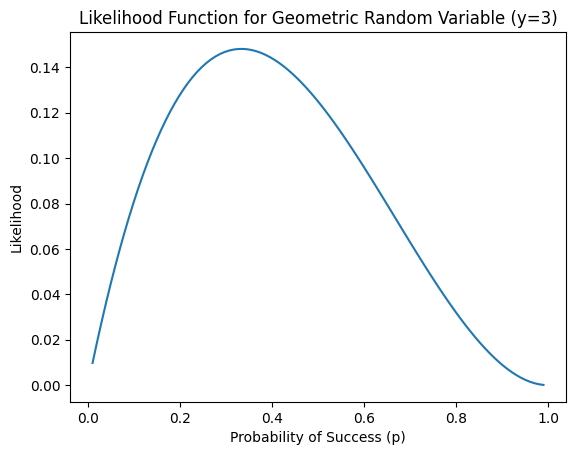

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range of possible probabilities (p)
p_values = np.linspace(0.01, 0.99, 100)

# Calculate the likelihood function for y = 3
likelihood = [(1 - p) ** 2 * p for p in p_values]

# Plot the likelihood function
plt.plot(p_values, likelihood)
plt.xlabel("Probability of Success (p)")
plt.ylabel("Likelihood")
plt.title("Likelihood Function for Geometric Random Variable (y=3)")
plt.show()


`(b) Your answer goes here`

## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

`(a) Your answer goes here`

In [ ]:
import numpy as np
from scipy import stats

# Data
tv_hours = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4])

# Sample statistics
n = len(tv_hours)
mean = np.mean(tv_hours)
sd = np.std(tv_hours, ddof=1)
se = sd / np.sqrt(n)

# 95% t confidence interval
confidence = 0.95
df = n - 1
t_crit = stats.t.ppf((1 + confidence) / 2, df)

margin_error = t_crit * se
lower = mean - margin_error
upper = mean + margin_error

print(f"n = {n}")
print(f"Sample mean = {mean:.3f}")
print(f"Sample standard deviation = {sd:.3f}")
print(f"Standard error = {se:.3f}")
print(f"95% confidence interval = ({lower:.3f}, {upper:.3f})")

n = 10
Sample mean = 1.700
Sample standard deviation = 1.337
Standard error = 0.423
95% confidence interval = (0.743, 2.657)


`(b) Your answer goes here`

In [ ]:
import numpy as np
from scipy import stats

# Data with the incorrect value 24 instead of 4
tv_hours = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 24])

# Sample statistics
n = len(tv_hours)
mean = np.mean(tv_hours)
sd = np.std(tv_hours, ddof=1)
se = sd / np.sqrt(n)

# 95% t confidence interval
confidence = 0.95
df = n - 1
t_crit = stats.t.ppf((1 + confidence) / 2, df)

margin_error = t_crit * se
lower = mean - margin_error
upper = mean + margin_error

print(f"n = {n}")
print(f"Sample mean = {mean:.3f}")
print(f"Sample standard deviation = {sd:.3f}")
print(f"Standard error = {se:.3f}")
print(f"95% confidence interval = ({lower:.3f}, {upper:.3f})")

n = 10
Sample mean = 3.700
Sample standard deviation = 7.212
Standard error = 2.281
95% confidence interval = (-1.459, 8.859)


## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

`Your answer goes here`

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Students.txt", sep=r"\s+")
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())   # check column names

tv = pd.to_numeric(df["tv"], errors="coerce").dropna()

n = len(tv)
mean = tv.mean()
sd = tv.std(ddof=1)
se = sd / np.sqrt(n)

t_crit = stats.t.ppf(0.975, n - 1)
lower = mean - t_crit * se
upper = mean + t_crit * se

print(f"n = {n}")
print(f"Mean = {mean:.2f}")
print(f"95% CI for mean weekly TV hours: ({lower:.2f}, {upper:.2f})")

['subject', 'gender', 'age', 'hsgpa', 'cogpa', 'dhome', 'dres', 'tv', 'sport', 'news', 'aids', 'veg', 'affil', 'ideol', 'relig', 'abor', 'affirm', 'life']
n = 60
Mean = 7.27
95% CI for mean weekly TV hours: (5.53, 9.00)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Students.txt", sep=r"\s+")

# Assuming gender: 0 = female, 1 = male
female_tv = pd.to_numeric(df.loc[df["gender"] == 0, "tv"], errors="coerce").dropna()
male_tv   = pd.to_numeric(df.loc[df["gender"] == 1, "tv"], errors="coerce").dropna()

# Sample statistics
n_f, n_m = len(female_tv), len(male_tv)
mean_f, mean_m = female_tv.mean(), male_tv.mean()
s_f, s_m = female_tv.std(ddof=1), male_tv.std(ddof=1)

# Difference in means: female - male
diff = mean_f - mean_m

# Welch standard error
se = np.sqrt((s_f**2 / n_f) + (s_m**2 / n_m))

# Welch degrees of freedom
df_welch = ((s_f**2/n_f + s_m**2/n_m)**2) / (
    ((s_f**2/n_f)**2 / (n_f - 1)) + ((s_m**2/n_m)**2 / (n_m - 1))
)

t_crit = stats.t.ppf(0.975, df_welch)
lower = diff - t_crit * se
upper = diff + t_crit * se

print(f"Females: n={n_f}, mean={mean_f:.2f}, sd={s_f:.2f}")
print(f"Males:   n={n_m}, mean={mean_m:.2f}, sd={s_m:.2f}")
print(f"Mean difference, female - male: {diff:.2f}")
print(f"95% CI for difference: ({lower:.2f}, {upper:.2f})")

Females: n=29, mean=6.50, sd=7.10
Males:   n=31, mean=7.98, sd=6.37
Mean difference, female - male: -1.48
95% CI for difference: (-4.98, 2.01)


## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

`Your answer goes here`

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load Houses data
df = pd.read_csv("Houses.txt", sep=r"\s+")
df.columns = df.columns.str.strip().str.lower()

# Price is in thousands of dollars
old_prices = pd.to_numeric(df.loc[df["new"] == 0, "price"], errors="coerce").dropna()
new_prices = pd.to_numeric(df.loc[df["new"] == 1, "price"], errors="coerce").dropna()

def summary(x):
    return pd.Series({
        "n": len(x),
        "mean": x.mean(),
        "sd": x.std(ddof=1),
        "median": x.median(),
        "min": x.min(),
        "max": x.max()
    })

print("Descriptive Statistics: Price in thousands of dollars")
print("\nOlder homes:")
print(summary(old_prices).round(2))

print("\nNew homes:")
print(summary(new_prices).round(2))

# Welch two-sample confidence interval for mean difference: new - old
n_new, n_old = len(new_prices), len(old_prices)
mean_new, mean_old = new_prices.mean(), old_prices.mean()
sd_new, sd_old = new_prices.std(ddof=1), old_prices.std(ddof=1)

diff = mean_new - mean_old
se = np.sqrt(sd_new**2 / n_new + sd_old**2 / n_old)

df_welch = (sd_new**2/n_new + sd_old**2/n_old)**2 / (
    ((sd_new**2/n_new)**2 / (n_new - 1)) +
    ((sd_old**2/n_old)**2 / (n_old - 1))
)

t_crit = stats.t.ppf(0.975, df_welch)
lower = diff - t_crit * se
upper = diff + t_crit * se

t_stat, p_value = stats.ttest_ind(new_prices, old_prices, equal_var=False)

print("\nInferential Analysis")
print(f"Mean difference, new - older: {diff:.2f} thousand dollars")
print(f"95% CI for difference: ({lower:.2f}, {upper:.2f}) thousand dollars")
print(f"Welch t-test: t = {t_stat:.3f}, p-value = {p_value:.4f}")

print("\nAssumptions")
print("1. The 100 home sales are representative of Gainesville home sales. This is very important.")
print("2. New and older home sale prices are independent. This is very important.")
print("3. Selling price is quantitative. This is required for comparing means.")
print("4. Each group is approximately normal or large enough for t methods. This is moderately important.")
print("5. Equal variances are not assumed because Welch's method is used.")

print("\nInterpretation")
if lower > 0:
    print("New homes have a significantly higher mean selling price than older homes.")
elif upper < 0:
    print("New homes have a significantly lower mean selling price than older homes.")
else:
    print("There is not enough evidence to conclude that mean selling prices differ.")

print("Practical importance should be judged by the size of the difference, not only the p-value.")

Descriptive Statistics: Price in thousands of dollars

Older homes:
n          89.00
mean      207.85
sd        121.04
median    190.80
min        31.50
max       880.50
dtype: float64

New homes:
n          11.00
mean      436.45
sd        219.83
median    427.50
min       158.85
max       866.25
dtype: float64

Inferential Analysis
Mean difference, new - older: 228.59 thousand dollars
95% CI for difference: (79.60, 377.59) thousand dollars
Welch t-test: t = 3.386, p-value = 0.0063

Assumptions
1. The 100 home sales are representative of Gainesville home sales. This is very important.
2. New and older home sale prices are independent. This is very important.
3. Selling price is quantitative. This is required for comparing means.
4. Each group is approximately normal or large enough for t methods. This is moderately important.
5. Equal variances are not assumed because Welch's method is used.

Interpretation
New homes have a significantly higher mean selling price than older homes.
Pra

## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


`Your answer goes here`

In [ ]:
import numpy as np
from scipy import stats

# --- State A ---
# Sample size
n_A = 100
# Number of successes (preferred Republican)
x_A = 59
# Hypothesized population proportion under H0
pi_0 = 0.50

# Sample proportion
p_A = x_A / n_A

# Standard error under the null hypothesis
se_A = np.sqrt(pi_0 * (1 - pi_0) / n_A)

# Z-statistic
z_A = (p_A - pi_0) / se_A

# P-value for Ha: pi > 0.50 (one-sided test)
p_value_A = stats.norm.sf(z_A) # sf is 1 - cdf for right-tailed test

print(f"--- State A ---")
print(f"Sample proportion (p_A): {p_A:.3f}")
print(f"Z-statistic (State A): {z_A:.3f}")
print(f"P-value (State A): {p_value_A:.4f}")


# --- State B ---
# Sample size
n_B = 1000
# Number of successes (preferred Republican)
x_B = 525

# Sample proportion
p_B = x_B / n_B

# Standard error under the null hypothesis
se_B = np.sqrt(pi_0 * (1 - pi_0) / n_B)

# Z-statistic
z_B = (p_B - pi_0) / se_B

# P-value for Ha: pi > 0.50 (one-sided test)
p_value_B = stats.norm.sf(z_B)

print(f"\n--- State B ---")
print(f"Sample proportion (p_B): {p_B:.3f}")
print(f"Z-statistic (State B): {z_B:.3f}")
print(f"P-value (State B): {p_value_B:.4f}")


# --- Comparison ---
print("\n--- Comparison and Reasoning ---")
if p_value_A < p_value_B:
    print("State A has stronger evidence supporting a Republican victory (smaller p-value).")
    print(f"P-value for State A ({p_value_A:.4f}) is less than P-value for State B ({p_value_B:.4f}).")
elif p_value_B < p_value_A:
    print("State B has stronger evidence supporting a Republican victory (smaller p-value).")
    print(f"P-value for State B ({p_value_B:.4f}) is less than P-value for State A ({p_value_A:.4f}).")
else:
    print("Both states have similar evidence supporting a Republican victory.")

print("Reasoning: A smaller P-value indicates stronger evidence against the null hypothesis (pi = 0.50) and in favor of the alternative hypothesis (pi > 0.50). Therefore, the state with the smaller P-value provides greater statistical evidence for a Republican victory.")


--- State A ---
Sample proportion (p_A): 0.590
Z-statistic (State A): 1.800
P-value (State A): 0.0359

--- State B ---
Sample proportion (p_B): 0.525
Z-statistic (State B): 1.581
P-value (State B): 0.0569

--- Comparison and Reasoning ---
State A has stronger evidence supporting a Republican victory (smaller p-value).
P-value for State A (0.0359) is less than P-value for State B (0.0569).
Reasoning: A smaller P-value indicates stronger evidence against the null hypothesis (pi = 0.50) and in favor of the alternative hypothesis (pi > 0.50). Therefore, the state with the smaller P-value provides greater statistical evidence for a Republican victory.


(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

`Your answer goes here`

In [ ]:
import numpy as np
from scipy import stats

# Prior parameters: Beta(alpha_prior, beta_prior)
alpha_prior = 50
beta_prior = 50

# --- State A ---
n_A = 100
x_A = 59  # Number of Republicans
failures_A = n_A - x_A

# Posterior parameters for State A
alpha_posterior_A = alpha_prior + x_A
beta_posterior_A = beta_prior + failures_A

# P(pi < 0.50 | Data_A) from posterior distribution
posterior_prob_A = stats.beta.cdf(0.50, a=alpha_posterior_A, b=beta_posterior_A)

print(f"--- Bayesian Analysis for State A ---")
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Observations: {x_A} successes, {failures_A} failures (n={n_A})")
print(f"Posterior: Beta({alpha_posterior_A}, {beta_posterior_A})")
print(f"P(pi < 0.50 | Data_A): {posterior_prob_A:.4f}")

# --- State B ---
n_B = 1000
x_B = 525  # Number of Republicans
failures_B = n_B - x_B

# Posterior parameters for State B
alpha_posterior_B = alpha_prior + x_B
beta_posterior_B = beta_prior + failures_B

# P(pi < 0.50 | Data_B) from posterior distribution
posterior_prob_B = stats.beta.cdf(0.50, a=alpha_posterior_B, b=beta_posterior_B)

print(f"\n--- Bayesian Analysis for State B ---")
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Observations: {x_B} successes, {failures_B} failures (n={n_B})")
print(f"Posterior: Beta({alpha_posterior_B}, {beta_posterior_B})")
print(f"P(pi < 0.50 | Data_B): {posterior_prob_B:.4f}")

# --- Comparison with Frequentist P-values and Explanation ---
print("\n--- Comparison and Explanation ---")

# Frequentist P-values from part (a) (assuming they were previously calculated and are available or re-calculated if needed)
# For consistency, I will use the values from the previous output: p_value_A = 0.0359, p_value_B = 0.0569
p_value_A_freq = 0.0359
p_value_B_freq = 0.0569

print(f"Frequentist P-value for State A (Ha: pi > 0.50): {p_value_A_freq:.4f}")
print(f"Frequentist P-value for State B (Ha: pi > 0.50): {p_value_B_freq:.4f}")

print("\nExplanation of Differences:")
print("The frequentist P-value is the probability of observing data as extreme or more extreme than what was observed, *assuming the null hypothesis is true* (P(Data | H0)). It does not directly tell us the probability of the hypothesis itself.")
print("A small frequentist P-value (like for State A) suggests evidence *against* H0 (pi=0.50) and *in favor of* Ha (pi>0.50).")
print("\nThe Bayesian posterior probability P(pi < 0.50 | Data) directly quantifies the probability that the true proportion is less than 0.50, *given the observed data and our prior beliefs*. It reflects our updated belief about the parameter after observing the data.")
print("A small Bayesian P(pi < 0.50 | Data) indicates that, given the data and prior, it's unlikely that the true proportion is less than 0.50, which provides evidence that pi > 0.50.")

print("\nFor State A:")
print(f"  Frequentist P-value (pi > 0.50): {p_value_A_freq:.4f}")
print(f"  Bayesian P(pi < 0.50 | Data):   {posterior_prob_A:.4f}")
print("  Both analyses provide strong evidence that pi > 0.50, as both values are small. The frequentist p-value is a probability of data, while the Bayesian value is a probability of the parameter.")

print("\nFor State B:")
print(f"  Frequentist P-value (pi > 0.50): {p_value_B_freq:.4f}")
print(f"  Bayesian P(pi < 0.50 | Data):   {posterior_prob_B:.4f}")
print("  The frequentist P-value for State B is higher than for State A, suggesting weaker evidence for pi > 0.50. The Bayesian P(pi < 0.50 | Data) is also relatively larger than for State A, indicating more uncertainty or less strong evidence that pi > 0.50, especially when considering the prior.")

print("\nKey Difference:")
print("The frequentist P-value is about the data given the null, whereas the Bayesian posterior probability is about the parameter given the data and prior. In this case, for both states, a smaller value from either method points towards stronger evidence for the Republican candidate's proportion being greater than 0.50. The Beta(50,50) prior is quite informative and centered at 0.50, reflecting a strong initial belief that the proportions are close to 0.50. The data for State A is strong enough to shift the posterior significantly away from 0.50, resulting in a small P(pi<0.50), similar to its frequentist p-value. For State B, even with a larger sample size, the observed proportion is closer to 0.50, and the prior still influences the posterior, leading to a larger P(pi<0.50) compared to State A.")

--- Bayesian Analysis for State A ---
Prior: Beta(50, 50)
Observations: 59 successes, 41 failures (n=100)
Posterior: Beta(109, 91)
P(pi < 0.50 | Data_A): 0.1009

--- Bayesian Analysis for State B ---
Prior: Beta(50, 50)
Observations: 525 successes, 475 failures (n=1000)
Posterior: Beta(575, 525)
P(pi < 0.50 | Data_B): 0.0657

--- Comparison and Explanation ---
Frequentist P-value for State A (Ha: pi > 0.50): 0.0359
Frequentist P-value for State B (Ha: pi > 0.50): 0.0569

Explanation of Differences:
The frequentist P-value is the probability of observing data as extreme or more extreme than what was observed, *assuming the null hypothesis is true* (P(Data | H0)). It does not directly tell us the probability of the hypothesis itself.
A small frequentist P-value (like for State A) suggests evidence *against* H0 (pi=0.50) and *in favor of* Ha (pi>0.50).

The Bayesian posterior probability P(pi < 0.50 | Data) directly quantifies the probability that the true proportion is less than 0.50, *g

## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

`Your answer goes here`

In [ ]:
import pandas as pd
from scipy import stats

df = pd.read_csv("Students.txt", sep=r"\s+")
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())   # check column names

# Political ideology column is usually named "ideol" or similar
ideology_col = "ideol"       # change this if your column name is different

x = pd.to_numeric(df[ideology_col], errors="coerce").dropna()

# One-sample t test: H0: mu = 4.0, Ha: mu != 4.0
t_stat, p_value = stats.ttest_1samp(x, popmean=4.0)

print(f"n = {len(x)}")
print(f"Sample mean = {x.mean():.2f}")
print(f"t statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0. The population mean political ideology differs from 4.0.")
else:
    print("Fail to reject H0. There is not enough evidence that the mean differs from 4.0.")

['subject', 'gender', 'age', 'hsgpa', 'cogpa', 'dhome', 'dres', 'tv', 'sport', 'news', 'aids', 'veg', 'affil', 'ideol', 'relig', 'abor', 'affirm', 'life']
n = 60
Sample mean = 3.03
t statistic = -4.577
P-value = 0.0000
Reject H0. The population mean political ideology differs from 4.0.


(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


`Your answer goes here`

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Students.txt", sep=r"\s+")
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

ideology_col = "ideol"   # change if needed

x = pd.to_numeric(df[ideology_col], errors="coerce").dropna()

n = len(x)
mean = x.mean()
sd = x.std(ddof=1)
se = sd / np.sqrt(n)

tcrit = stats.t.ppf(0.975, n - 1)
lower = mean - tcrit * se
upper = mean + tcrit * se

print(f"n = {n}")
print(f"Sample mean = {mean:.2f}")
print(f"95% CI for mu: ({lower:.2f}, {upper:.2f})")

['subject', 'gender', 'age', 'hsgpa', 'cogpa', 'dhome', 'dres', 'tv', 'sport', 'news', 'aids', 'veg', 'affil', 'ideol', 'relig', 'abor', 'affirm', 'life']
n = 60
Sample mean = 3.03
95% CI for mu: (2.61, 3.46)


## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

`Your answer goes here`

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load the Sheep data file
try:
    # Assuming 'Sheep.txt' is in the same directory or accessible
    df_sheep = pd.read_csv('Sheep.txt', sep=r'\s+')
    df_sheep.columns = df_sheep.columns.str.strip().str.lower() # Clean column names
except FileNotFoundError:
    print("Error: 'Sheep.txt' not found. Please upload the file.")
    exit()

# Ensure required columns exist
if 'survival' not in df_sheep.columns or 'weight' not in df_sheep.columns:
    print("Error: 'survival' or 'weight' column not found in the Sheep data file.")
    print("Available (cleaned) columns: ", df_sheep.columns.tolist())
    print("Please check the column names and update the code if necessary.")
    exit()

# Separate data into survived and not survived groups
# Assuming survival: 1 = yes, 0 = no
weight_survived = pd.to_numeric(df_sheep.loc[df_sheep['survival'] == 1, 'weight'], errors='coerce').dropna()
weight_not_survived = pd.to_numeric(df_sheep.loc[df_sheep['survival'] == 0, 'weight'], errors='coerce').dropna()

print("--- Descriptive Statistics ---")
print(f"Survived (n={len(weight_survived)}): Mean Weight = {weight_survived.mean():.2f} kg, SD = {weight_survived.std():.2f} kg")
print(f"Not Survived (n={len(weight_not_survived)}): Mean Weight = {weight_not_survived.mean():.2f} kg, SD = {weight_not_survived.std():.2f} kg")

# Perform independent two-sample t-test (Welch's t-test for unequal variances)
# H0: Mean weight of survived sheep = Mean weight of not survived sheep
# Ha: Mean weight of survived sheep != Mean weight of not survived sheep (two-sided)

t_stat, p_value = stats.ttest_ind(weight_survived, weight_not_survived, equal_var=False)

print("\n--- Two-Sample t-test (Welch's) ---")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

print("\n--- Assumptions ---")
print("1. Independence: The weights of individual sheep are independent, and the two groups (survived/not survived) are independent. (Very important)")
print("2. Random Sampling: The sheep samples (or the process leading to their observation) are representative of the conceptual populations of sheep that would survive or not survive under similar conditions. The conceptual population of interest includes all sheep that could be subject to similar environmental factors and observation conditions. (Very important)")
print("3. Normality or Large Sample Size: The weights within each group are approximately normally distributed, or the sample sizes are large enough for the Central Limit Theorem to apply to the sampling distribution of the means. (Moderately important; t-test is robust to moderate departures from normality, especially with larger samples. Visual inspection or formal tests could check this assumption.)")
print("4. Measurement Scale: Weight is a quantitative variable. (Required)")
print("5. Equal Variances: Not assumed, as Welch's t-test (equal_var=False) is used, which is robust to unequal variances. (Not important for Welch's test)")

print("\n--- Interpretation of P-value ---")
alpha = 0.05 # Common significance level
if p_value < alpha:
    print(f"With a P-value of {p_value:.4f}, which is less than the significance level (alpha = {alpha}), we reject the null hypothesis.")
    print("This suggests there is statistically significant evidence that the mean weights of sheep that survived and did not survive are different.")
else:
    print(f"With a P-value of {p_value:.4f}, which is greater than the significance level (alpha = {alpha}), we fail to reject the null hypothesis.")
    print("This suggests there is not enough statistically significant evidence to conclude that the mean weights of sheep that survived and did not survive are different.")


--- Descriptive Statistics ---
Survived (n=1041): Mean Weight = 20.65 kg, SD = 4.90 kg
Not Survived (n=318): Mean Weight = 16.00 kg, SD = 5.33 kg

--- Two-Sample t-test (Welch's) ---
T-statistic: 13.870
P-value: 0.0000

--- Assumptions ---
1. Independence: The weights of individual sheep are independent, and the two groups (survived/not survived) are independent. (Very important)
2. Random Sampling: The sheep samples (or the process leading to their observation) are representative of the conceptual populations of sheep that would survive or not survive under similar conditions. The conceptual population of interest includes all sheep that could be subject to similar environmental factors and observation conditions. (Very important)
3. Normality or Large Sample Size: The weights within each group are approximately normally distributed, or the sample sizes are large enough for the Central Limit Theorem to apply to the sampling distribution of the means. (Moderately important; t-test is r

## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

(a) `Your answer goes here`

In [ ]:
import pandas as pd

contingency_table = pd.crosstab(df_ai['sentiment'], df_ai['gender'])
print(contingency_table)

gender     Female  Male  Other
sentiment                     
Negative       30    38      3
Neutral        48    49      0
Positive       63    63      6


(b) `Your answer goes here`


In [ ]:
from scipy.stats import chi2_contingency

# Perform the chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies table:")
print(expected.round(2))

Chi-squared statistic: 5.116
P-value: 0.2756
Degrees of freedom: 4
Expected frequencies table:
[[33.37 35.5   2.13]
 [45.59 48.5   2.91]
 [62.04 66.    3.96]]


(c) `Your answer goes here`


The results of the chi-squared test are:
- **Chi-squared statistic**: 5.116
- **P-value**: 0.2756
- **Degrees of freedom**: 4

**Interpretation in the context of attitudes toward AI:**

1.  **Hypothesis**: The null hypothesis ($H_0$) states that sentiment toward AI is independent of gender. The alternative hypothesis ($H_a$) states that sentiment toward AI is *not* independent of gender (i.e., there is an association).

2.  **P-value**: With a P-value of 0.2756, which is much greater than a common significance level like $\alpha$ = 0.05 (or even 0.10), we **fail to reject the null hypothesis**.

3.  **Conclusion**: This means that, based on the collected sample data, there is **not enough statistically significant evidence to conclude that sentiment toward AI is dependent on gender**. In simpler terms, we cannot say that a person's gender influences their sentiment (positive, neutral, or negative) towards AI, or vice versa, according to this dataset. The observed differences in sentiment across gender categories in the contingency table are likely due to random sampling variability.